In [ ]:
# Installation des dépendances
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn folium scikit-learn joblib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports et configuration

Import des bibliothèques nécessaires :
- `pandas` / `numpy` : manipulation des données
- `matplotlib` / `seaborn` : visualisations statiques
- `folium` : cartes interactives (OpenStreetMap)
- `os` : gestion des fichiers

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

os.makedirs("output", exist_ok=True)


## Chargement des données

Lecture du fichier CSV exporté depuis le registre national des bornes de recharge (IRVE).
Le dataset contient ~138 000 points de charge avec 47 colonnes (opérateur, localisation, puissance, horaires, etc.).

In [29]:
df = pd.read_csv("export_IA.csv")

print(f"Jeu de données chargé : {df.shape[0]} lignes et {df.shape[1]} colonnes.")
df.head()


Jeu de données chargé : 138934 lignes et 47 colonnes.


C:\Users\dacks\AppData\Local\Temp\ipykernel_25732\573833406.py:1: DtypeWarning: Columns (0: code_insee, 1: prise_ef, 2: prise_type2, 3: prise_ccs, 4: prise_chademo, 5: prise_autre, 6: deux_roues, 7: paiement_acte, 8: paiement_cb, 9: reservation) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("export_IA.csv")


,id_pdc,id_station,id_station_local,id_pdc_local,nom_station,nom_amenageur,siren_amenageur,contact_amenageur,operateur,contact_operateur,...,gratuit,paiement_acte,paiement_cb,paiement_autre,tarification_brute,condition_acces,reservation,horaires,date_service,date_maj
0,DKMONE3785539,DKMONE3785539,NaN,NaN,Golf de Garonne,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,False,False,NaN,Accès libre,False,Mo-Su 08:00-19:00,2024-10-24,2024-10-23
1,DKMONE3785590,DKMONE3785539,NaN,NaN,Golf de Garonne,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,False,False,NaN,Accès libre,False,Mo-Su 08:00-19:00,2024-10-24,2024-10-23
2,DKMONE3785709,DKMONE3785709,NaN,NaN,Montestruc,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,True,False,NaN,Accès libre,False,24/7,2024-11-28,2025-01-30
3,DKMONE3785711,DKMONE3785711,NaN,NaN,Montestruc,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,True,False,NaN,Accès libre,False,24/7,2024-11-28,2025-01-30
4,DKMONE3785713,DKMONE3785713,NaN,NaN,Montestruc,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,False,False,NaN,Accès libre,False,24/7,2024-11-28,2025-01-30


## Vérification des données

Exploration rapide du dataset avant toute transformation : types de colonnes, valeurs manquantes, doublons, statistiques descriptives.
Permet de détecter des anomalies (coordonnées hors France, puissances aberrantes) et de valider la cohérence des données.

In [30]:
print("=== Dimensions ===")
print(f"{df.shape[0]} lignes, {df.shape[1]} colonnes\n")

print("=== Types des colonnes ===")
print(df.dtypes, "\n")

print("=== Valeurs manquantes (top 15 colonnes) ===")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(15), "\n")

print("=== Doublons ===")
print(f"Lignes dupliquées : {df.duplicated().sum()}\n")

print("=== Statistiques descriptives (colonnes numériques) ===")
df.describe()

=== Dimensions ===
138934 lignes, 47 colonnes

=== Types des colonnes ===
id_pdc                     str
id_station                 str
id_station_local           str
id_pdc_local               str
nom_station                str
nom_amenageur              str
siren_amenageur        float64
contact_amenageur          str
operateur                  str
contact_operateur          str
telephone_operateur        str
enseigne                   str
code_pays_operateur        str
code_operateur             str
adresse                    str
code_insee              object
commune                    str
code_postal              int64
longitude              float64
latitude               float64
implantation               str
nb_pdc                   int64
puissance              float64
prise_ef                object
prise_type2             object
prise_ccs               object
prise_chademo           object
prise_autre             object
pmr                    float64
restriction_gabarit        

,siren_amenageur,code_postal,longitude,latitude,nb_pdc,puissance,pmr,prix_kwh_norm,prix_min_norm
count,7.913500e+04,138934.000000,138934.000000,138934.000000,138934.000000,138934.000000,0.0,17200.000000,1435.000000
mean,6.916839e+08,52907.580067,2.687405,46.935130,16.896015,61.914964,NaN,0.359546,0.040103
std,2.611120e+08,26708.337006,2.686106,2.310958,54.989963,87.831177,NaN,0.156020,0.048561
min,0.000000e+00,1000.000000,-4.770307,41.387182,0.000000,1.400000,NaN,0.000000,0.000000
25%,4.508892e+08,31400.000000,1.075627,44.853898,2.000000,22.000000,NaN,0.320000,0.000000
50%,8.427185e+08,57515.000000,2.428733,47.424467,4.000000,22.000000,NaN,0.334200,0.025000
75%,8.916249e+08,75016.000000,4.834654,48.871139,9.000000,50.000000,NaN,0.390000,0.060000
max,9.853304e+08,95880.000000,9.553642,51.063125,505.000000,500.000000,NaN,15.000000,0.550000


## Sélection et nettoyage des colonnes utiles

**Variables retenues :** `latitude`, `longitude`, `implantation`, `puissance`.

**Justification du choix des variables :**
- `latitude` / `longitude` : indispensables pour tout affichage cartographique.
- `implantation` : variable cible du besoin 1 — identifier le *type* de lieu (parking public, voirie, station rapide…). Permet de distinguer les usages et de détecter des implantations incohérentes.
- `puissance` : indicateur de la capacité de charge. Combinée à l'implantation, elle permet de valider la cohérence (ex. charge rapide sur autoroute vs charge lente en parking résidentiel).

Les 43 autres colonnes (opérateur, contact, tarification, horaires…) ne sont pas nécessaires pour les visualisations cartographiques de ce besoin.

**Justification du nettoyage :** suppression des lignes avec valeurs manquantes (`dropna`) sur ces 4 colonnes uniquement — une coordonnée ou un type manquant rend la ligne inutilisable pour la carte.

In [31]:
colonnes_interet = ['latitude', 'longitude', 'implantation', 'puissance']
df_b1 = df[colonnes_interet].dropna().copy()
print(f"Nombre de lignes exploitables pour les cartes : {df_b1.shape[0]}")

Nombre de lignes exploitables pour les cartes : 138934


## Encodage des données catégorielles

**Justification du choix de LabelEncoder :**
- `implantation` est une variable catégorielle ordinale (5 classes). `LabelEncoder` attribue un entier à chaque classe.
- Alternative envisagée : `OneHotEncoder` — adapté pour les modèles linéaires sensibles aux relations ordinales artificielles. Ici, `LabelEncoder` est suffisant car l'encodage sera utilisé pour des algorithmes capables de gérer des entiers arbitraires (arbres de décision, clustering).
- L'encodeur est sauvegardé (`joblib`) pour pouvoir inverser la transformation lors des prédictions futures sans risque de désalignement des classes.

In [32]:
import joblib
from sklearn.preprocessing import LabelEncoder

le_implantation = LabelEncoder()
df_b1['implantation_encoded'] = le_implantation.fit_transform(df_b1['implantation'])

print("Correspondance des classes encodées :")
for index, classe in enumerate(le_implantation.classes_):
    print(f"  {classe} -> {index}")

joblib.dump(le_implantation, "encoder_implantation.pkl")
print("Encodeur sauvegardé avec succès !")


Correspondance des classes encodées :
  Parking privé réservé à la clientèle -> 0
  Parking privé à usage public -> 1
  Parking public -> 2
  Station dédiée à la recharge rapide -> 3
  Voirie -> 4
Encodeur sauvegardé avec succès !


## Fonction : carte filtrable par type d'implantation

**Justification du choix de Folium + MarkerCluster + FeatureGroup :**
- **Folium** : bibliothèque Python légère basée sur Leaflet.js. Produit des cartes HTML interactives sans serveur — idéal pour partager des résultats en standalone.
- **MarkerCluster** : regroupe automatiquement les marqueurs proches à faible zoom. Nécessaire ici car le dataset contient ~139 000 points — afficher tous les marqueurs individuellement rendrait la carte inutilisable.
- **FeatureGroup par type d'implantation** : permet d'activer/désactiver chaque catégorie via le contrôle de couches. L'utilisateur peut ainsi isoler un type et détecter visuellement des anomalies de localisation.

La carte est centrée sur la France (`[46.22, 2.21]`, zoom 6) pour englober tout le territoire dès l'ouverture.

Génère une carte Folium avec un calque (`FeatureGroup`) par type d'implantation.
Chaque calque utilise un `MarkerCluster` pour regrouper les marqueurs à faible zoom.
Un contrôle de couches permet à l'utilisateur de filtrer les types directement sur la carte.

In [33]:
def generer_carte_implantation(df_source, chemin_sortie, message_succes):
    carte = folium.Map(location=[46.2276, 2.2137], zoom_start=6)

    for type_impl, sous_df in df_source.groupby('implantation'):
        calque = folium.FeatureGroup(name=f"Implantation : {type_impl}")
        cluster = MarkerCluster(options={'maxClusterRadius': 50}).add_to(calque)

        for lat, lon in sous_df[['latitude', 'longitude']].values:
            folium.Marker(location=[lat, lon]).add_to(cluster)

        calque.add_to(carte)

    folium.LayerControl(collapsed=False).add_to(carte)
    carte.save(chemin_sortie)
    print(message_succes)
    return carte

## Graphique : distribution par type d'implantation

Barplot horizontal (seaborn) montrant le nombre de bornes par type d'implantation, trié par fréquence décroissante.
Le graphique est sauvegardé en PNG.

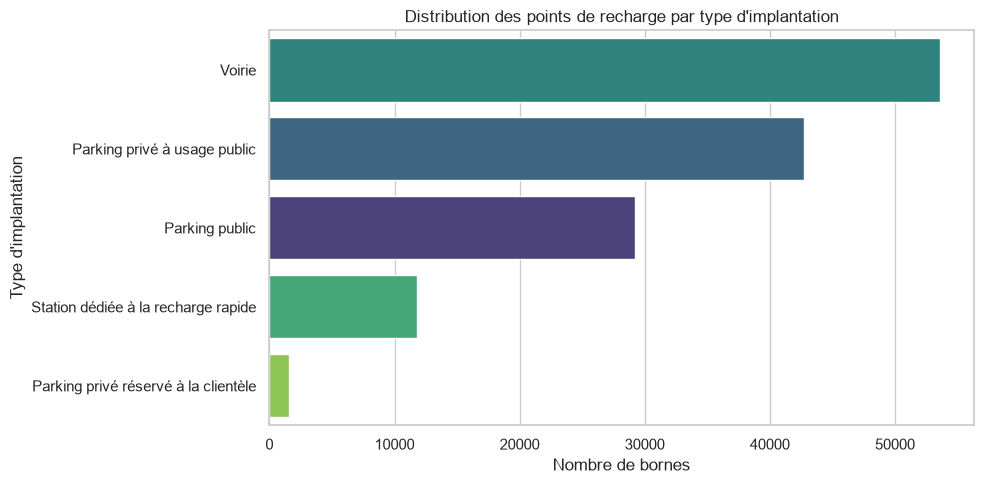

In [34]:
plt.figure(figsize=(10, 5))
sns.countplot(
    y='implantation', 
    data=df_b1, 
    order=df_b1['implantation'].value_counts().index, 
    hue='implantation',
    legend=False,
    palette='viridis'
)
plt.title("Distribution des points de recharge par type d'implantation")
plt.xlabel("Nombre de bornes")
plt.ylabel("Type d'implantation")
plt.tight_layout()
plt.savefig("output/distribution_implantation.png")
plt.show()


## Génération de la carte filtrable

Appel de la fonction `generer_carte_implantation` sur l'ensemble du dataset.
Résultat : fichier HTML interactif avec filtrage par type d'implantation.

In [35]:
print("Génération de la carte filtrable par type d'implantation...")
carte_filtrable = generer_carte_implantation(
    df_b1,
    "output/carte_implantation_filtrable.html",
    "Carte filtrable enregistrée avec succès !",
)


Génération de la carte filtrable par type d'implantation...
Carte filtrable enregistrée avec succès !


## Carte de chaleur (heatmap)

**Justification du choix de HeatMap Folium :**
- Représente la *densité spatiale* des bornes, pas leur type — complémentaire à la carte par implantation.
- `HeatMap` de Folium utilise un noyau gaussien : chaque point contribue à ses voisins avec décroissance progressive. Permet de visualiser les zones de concentration sans surcharger la carte de marqueurs.
- `radius=10` : rayon d'influence de chaque point en pixels — assez petit pour distinguer les clusters urbains.
- `blur=15` : lissage du dégradé — évite un effet "grêle" sur les zones denses.
- `min_opacity=0.5` : les zones peu denses restent visibles (sans ce paramètre elles disparaissent).

Carte de densité montrant la concentration géographique des bornes sur le territoire français.

In [36]:
carte_chaleur = folium.Map(location=[46.2276, 2.2137], zoom_start=6)

coordonnees = df_b1[['latitude', 'longitude']].values.tolist()

HeatMap(coordonnees, radius=10, blur=15, min_opacity=0.5).add_to(carte_chaleur)

chemin_carte_heat = "output/carte_chaleur.html"
carte_chaleur.save(chemin_carte_heat)
print("Carte de chaleur enregistrée avec succès !")


Carte de chaleur enregistrée avec succès !


## Graphique : distribution de la puissance nominale

Histogramme avec courbe de densité (KDE) de la puissance des bornes, filtré à ≤ 150 kW pour exclure les valeurs extrêmes qui écraseraient l'échelle.
Permet d'identifier les puissances les plus communes (charge lente ~7 kW, rapide ~50 kW, ultra-rapide ~150 kW).

C:\Users\dacks\AppData\Local\Temp\ipykernel_25732\2808357397.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_b1[df_b1['puissance'] <= 150], x='puissance', bins=30, kde=True, palette='magma')


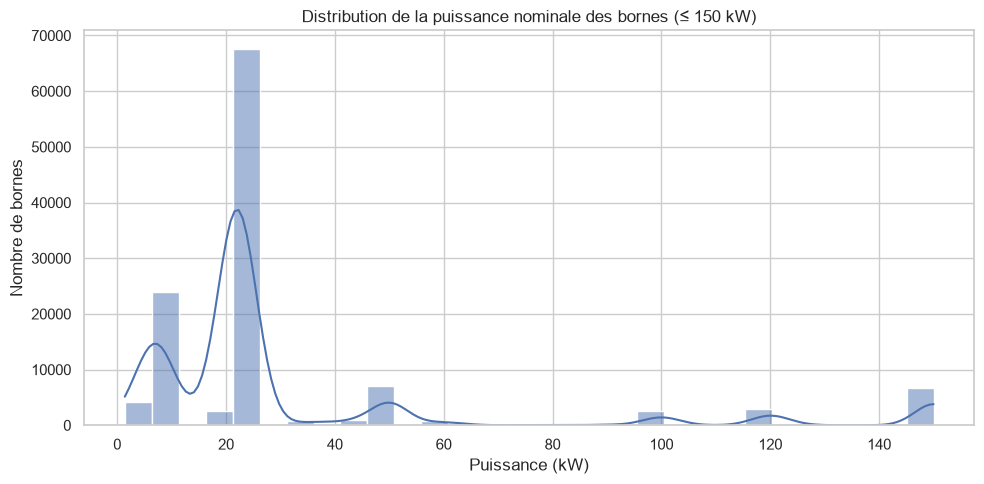

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_b1[df_b1['puissance'] <= 150], x='puissance', bins=30, kde=True, palette='magma')
plt.title("Distribution de la puissance nominale des bornes (≤ 150 kW)")
plt.xlabel("Puissance (kW)")
plt.ylabel("Nombre de bornes")
plt.tight_layout()
plt.savefig("output/distribution_puissance.png")
plt.show()
